<h1>Lennard Jones Potential</h1>

In this notebook we investigate a system of atoms interacting under the Lennard-Jones pair potential. Atoms are initialised in a face-centered cubic lattice with a minimal unit cell repeated 3 $\times$ 3 $\times$ 3 times. There are periodic boundary conditions in all directions.

The Lennard Jones potential is:

$$
V(r) = 4 \left[ \frac{1}{r^{12}} - \frac{1}{r^{6}}\right]
$$

In [93]:
import numpy as np
import matplotlib.pyplot as plt

Code in the below cell has been copied from the MTH4332 tutorials. This implements a pairwise calculator for a given pair potential.

In [95]:
import ase
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from ase.build import bulk,make_supercell
from ase.visualize import view
from ase.io import write
from ase.neighborlist import NeighborList
from ase.calculators.calculator import Calculator, all_changes
from ase.stress import full_3x3_to_voigt_6_stress
from ase.lattice.cubic import FaceCenteredCubic
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.langevin import Langevin
from ase.io.trajectory import Trajectory

class pairwise_calculator(Calculator) :
  """Implementation of a very basic Lennard Jones Calculator"""

  implemented_properties = ['energy', 'energies', 'forces', 'free_energy']
  implemented_properties += ['stress', 'stresses']  # bulk properties
  default_parameters = {'rc': None,}
  nolabel = True

  def __init__(self, **kwargs ) :
    Calculator.__init__( self, **kwargs )
    if self.parameters.pairwise_e is None :
      ValueError("function for evaluating pairwise energies has not been set")
    # Setup a cutoff value so we can use a neighbour list
    if self.parameters.rc is None :
      ValueError("cutoff for pairwise interactions should be set")
    # Setup stuff for neighbour list
    self.nl = None
    self.pairwise_e = self.parameters.pairwise_e
    self.parameters.pairwise_e = None

  def calculate( self, atoms=None, properties=None, system_changes=all_changes, ) :
    if properties is None : properties = self.implemented_properties

    Calculator.calculate(self, atoms, properties, system_changes)

    natoms = len(self.atoms)

    rc = self.parameters.rc
    # potential value at rc
    e0, f0 = self.pairwise_e( rc )

    if self.nl is None or 'numbers' in system_changes:
        self.nl = NeighborList([rc / 2] * natoms, self_interaction=False, bothways=True )

    self.nl.update(self.atoms)

    positions = self.atoms.positions
    cell = self.atoms.cell

    energies = np.zeros(natoms)
    forces = np.zeros((natoms, 3))
    stresses = np.zeros((natoms, 3, 3))

    for ii in range(natoms):
        neighbors, offsets = self.nl.get_neighbors(ii)
        cells = np.dot(offsets, cell)

        # pointing *towards* neighbours
        distance_vectors = positions[neighbors] + cells - positions[ii]

        r = np.sqrt( (distance_vectors ** 2).sum(1) )
        pairwise_energies, pairwise_forces = self.pairwise_e( r )
        pairwise_energies[r > rc] = 0.0
        pairwise_forces[r > rc] = 0.0

        pairwise_forces = pairwise_forces[:, np.newaxis] * distance_vectors
        energies[ii] += 0.5 * pairwise_energies.sum()  # atomic energies
        forces[ii] += pairwise_forces.sum(axis=0)
        stresses[ii] += 0.5 * np.dot(pairwise_forces.T, distance_vectors)

    # no lattice, no stress
    if self.atoms.cell.rank == 3:
        stresses = full_3x3_to_voigt_6_stress(stresses)
        self.results['stress'] = stresses.sum(axis=0) / self.atoms.get_volume()
        self.results['stresses'] = stresses / self.atoms.get_volume()

    energy = energies.sum()
    self.results['energy'] = energy
    self.results['energies'] = energies
    self.results['free_energy'] = energy
    self.results['forces'] = forces

<h2>Pair Potential</h2>

-0.0009763240814208984


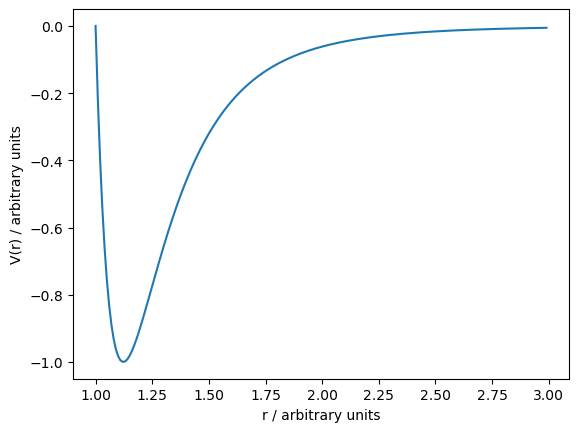

In [97]:
def pairPotential(r):
    return 4 * ((1/r)**12 - (1/r)**6)

def pairEnergyForce(r):
    energy = 4 * ((1/r)**12 - (1/r)**6)
    force = -48 * (1/r)**14 + 24 * (1/r)**8

    return energy, force

x = np.arange(1, 3, 0.01)
y = pairPotential(x)

plt.plot(x, y)

plt.xlabel("r / arbitrary units")
plt.ylabel("V(r) / arbitrary units")

print(pairPotential(4))

<h2>MD Simulation</h2>
Atoms are initialised with the minimal unit cell repeated $3^3$ times, with a lattice constant of $2^{2/3}$ and periodic boundary conditions in each direction.
\\

We assume the potential to be zero at distances greater than 4 as an approximation. The potential at 4 is $-9.7 \times 10^{-4}$.


We perform the MD simulation using the ase Langevin module. We store the results in a .traj file.

We perform the simulation with a timestep of $0.005$, $k_bT=2$ and a friction coefficient of $1.0$. We run for 1000 simulation steps. 

In [99]:
timestep = 0.005
temp = 2

iterations = 10000
interval = 10

#Initialising atoms object
atoms = FaceCenteredCubic(directions = [[1, 0, 0], [0, 1, 0], [0, 0, 1]], symbol='Ar', size=(3, 3, 3), latticeconstant = 2**(2/3), pbc=(1, 1, 1))
atoms.set_masses(np.ones(len(atoms)))
MaxwellBoltzmannDistribution(atoms, temp)

#Attatching energy and force calculator
atoms.calc = pairwise_calculator(rc = 4, pairwise_e = pairEnergyForce)

#Applying MD
dynamicCalculator = Langevin( atoms, timestep, temp, 1.0 )

traj = Trajectory('trajectory.traj', 'w', atoms)

dynamicCalculator.attach(traj.write, interval=interval)
dynamicCalculator.run(iterations)

traj.close()

<h2>Energy Plot</h2>

Text(0, 0.5, 'Potential Energy / arbitrary units')

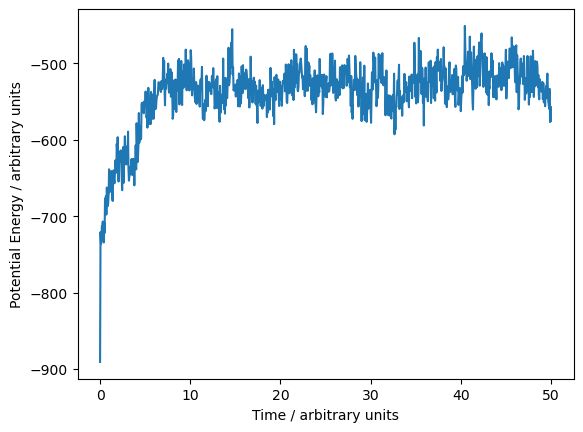

In [101]:
trajectory = Trajectory('trajectory.traj')

energies = np.zeros(len(trajectory))
times = np.arange(0, timestep * (iterations + 1), timestep * interval)

for i in range(len(trajectory)):
    energies[i] = trajectory[i].get_potential_energy()

plt.plot(times, energies)
plt.xlabel("Time / arbitrary units")
plt.ylabel("Potential Energy / arbitrary units")

In [102]:
#We remove the first 10 seconds of equilibriation
trajectory = trajectory[int(10/(timestep * interval)):]

<h2>Radial Distribution Function</h2>
We estimate a radial distribution function for the distances between every pair of atoms, in every frame, by computing a histogram.

Text(0, 0.5, 'g(r)')

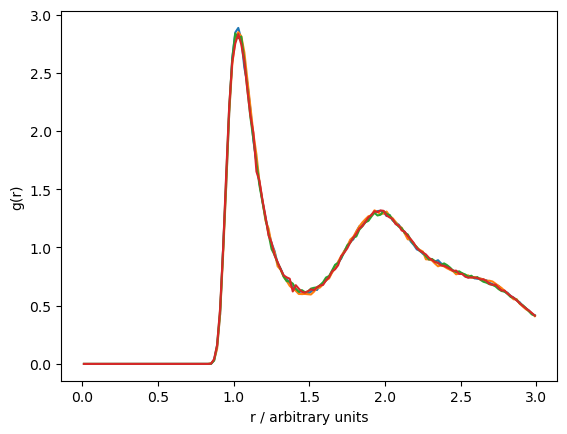

In [104]:
maxd, nbins = 3, 150
dx = maxd / nbins

def getDistribution(partialTrajectory):
    
    histogram = np.zeros(nbins)
    
    numFrames = len(partialTrajectory)
    Natoms = len(partialTrajectory[0])
    V = partialTrajectory[0].get_volume()
    
    #Creating histogram for distances
    for atoms in partialTrajectory:
        distances = atoms.get_all_distances( mic=True )
        
        for i in range(1,distances.shape[0]):
          for j in range(0,i): 
              if  distances[i,j] < maxd:
                  binInd = int(distances[i, j] / dx)
                  histogram[binInd] += 2
    
    #Normalisation to produce the radial distribution function
    for i in range(nbins):
      volume = 0
      if i==0:
        volume = (4 * np.pi/3) * dx**3 * (Natoms/V)
      else:
        volume = (4 * np.pi/3) * (i*dx)**3 - (4 * np.pi/3) * ((i-1)*dx)**3 * (Natoms/V)
      
      histogram[i] /= numFrames * Natoms * volume

    #print(histogram)
    return histogram

binCenters = np.arange(0.5*dx, nbins*dx, dx)

blockSize = len(trajectory) // 5
for i in range(1, 5):
    plt.plot(binCenters, getDistribution(trajectory[i * blockSize : (i+1) * blockSize]))


#Plotting Radial Distribution function
plt.xlabel('r / arbitrary units')
plt.ylabel('g(r)')

Text(0, 0.5, 'g(r)')

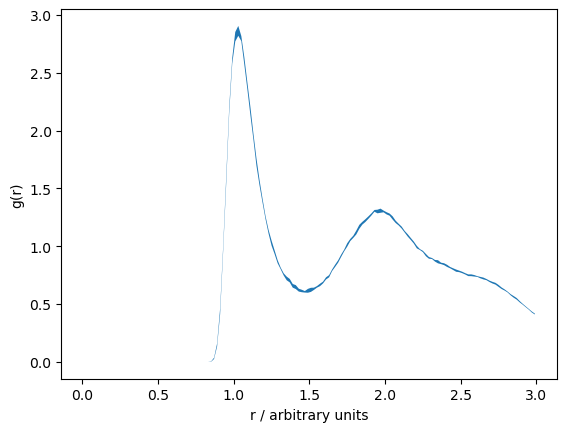

In [105]:
#Returns an average and an error for each blocksize
def blockAveraging(blockSize):
    numBlocks = len(trajectory) // blockSize

    averages = np.zeros(nbins)
    sqaverages = np.zeros(nbins)
    for i in range(numBlocks):
        distribution = getDistribution(trajectory[i * blockSize : (i+1) * blockSize])
        averages += distribution
        sqaverages += np.power(distribution, 2)

    averages /= numBlocks
    sqaverages /= numBlocks
    
    variances = sqaverages - np.power(averages, 2)

    errors = np.sqrt(variances/numBlocks) * 1.96 #For 95% confidence
    
    return averages, errors


avg, err = blockAveraging(100)
binCenters = np.arange(0.5*dx, nbins*dx, dx)

#Creating a solid surface for the error plot
lowerLine = avg - err
upperLine = avg + err

plt.fill_between(binCenters, lowerLine, upperLine)

plt.xlabel('r / arbitrary units')
plt.ylabel('g(r)')

<h2>Repeating the simulation for lower temperature</h2>

Text(0, 0.5, 'g(r)')

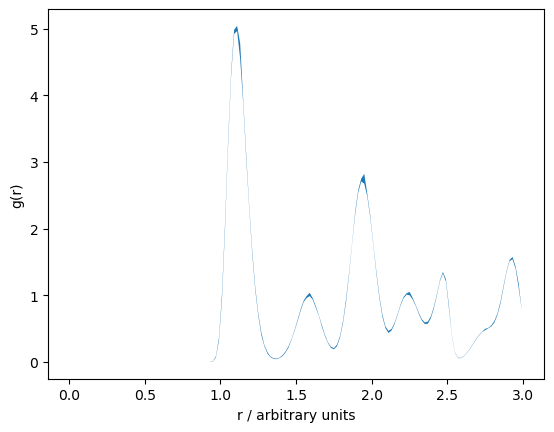

In [107]:
timestep = 0.005
temp = 0.5

iterations = 10000
interval = 10

#Initialising atoms object
atoms = FaceCenteredCubic(directions = [[1, 0, 0], [0, 1, 0], [0, 0, 1]], symbol='Ar', size=(3, 3, 3), latticeconstant = 2**(2/3), pbc=(1, 1, 1))
atoms.set_masses(np.ones(len(atoms)))
MaxwellBoltzmannDistribution(atoms, temp)

#Attatching energy and force calculator
atoms.calc = pairwise_calculator(rc = 4, pairwise_e = pairEnergyForce)

#Applying MD
dynamicCalculator = Langevin( atoms, timestep, temp, 1.0 )

traj = Trajectory('trajectory.traj', 'w', atoms)

dynamicCalculator.attach(traj.write, interval=interval)
dynamicCalculator.run(iterations)
traj.close()

trajectory = Trajectory('trajectory.traj')

#ERROR CALCULATIONS
avg, err = blockAveraging(100)
binCenters = np.arange(0.5*dx, nbins*dx, dx)

#Creating a solid surface for the error plot
lowerLine = avg - err
upperLine = avg + err

plt.fill_between(binCenters, lowerLine, upperLine)

plt.xlabel('r / arbitrary units')
plt.ylabel('g(r)')